In [19]:
from pathlib import Path

raw = Path("data/raw")

for item in raw.iterdir():
    print(item.name, "| file:", item.is_file(), "| folder:", item.is_dir())

g_assignee_disambiguated.tsv | file: False | folder: True
g_inventor_disambiguated.tsv | file: False | folder: True
g_location_disambiguated.tsv | file: False | folder: True
g_patent.tsv | file: False | folder: True
g_patent_abstract.tsv | file: False | folder: True
g_persistent_assignee.tsv | file: False | folder: True
g_persistent_inventor.tsv | file: False | folder: True


In [5]:
from pathlib import Path

raw = Path("data/raw")

for folder in raw.iterdir():
    print("\n")
    print(folder.name)
    print(" ")
    
    if folder.is_dir():
        for item in folder.rglob("*"):
            if item.is_file():
                print(item)



g_assignee_disambiguated.tsv
 
data\raw\g_assignee_disambiguated.tsv\g_assignee_disambiguated.tsv


g_inventor_disambiguated.tsv
 
data\raw\g_inventor_disambiguated.tsv\g_inventor_disambiguated.tsv


g_location_disambiguated.tsv
 
data\raw\g_location_disambiguated.tsv\g_location_disambiguated.tsv


g_patent.tsv
 
data\raw\g_patent.tsv\g_patent.tsv


g_patent_abstract.tsv
 
data\raw\g_patent_abstract.tsv\g_patent_abstract.tsv


g_persistent_assignee.tsv
 
data\raw\g_persistent_assignee.tsv\g_persistent_assignee.tsv


g_persistent_inventor.tsv
 
data\raw\g_persistent_inventor.tsv\g_persistent_inventor.tsv


In [6]:
import pandas as pd
from pathlib import Path

files = {
    "patents": Path("data/raw/g_patent.tsv/g_patent.tsv"),
    "abstracts": Path("data/raw/g_patent_abstract.tsv/g_patent_abstract.tsv"),
    "inventors": Path("data/raw/g_inventor_disambiguated.tsv/g_inventor_disambiguated.tsv"),
    "assignees": Path("data/raw/g_assignee_disambiguated.tsv/g_assignee_disambiguated.tsv"),
    "locations": Path("data/raw/g_location_disambiguated.tsv/g_location_disambiguated.tsv"),
    "persistent_inventor": Path("data/raw/g_persistent_inventor.tsv/g_persistent_inventor.tsv"),
    "persistent_assignee": Path("data/raw/g_persistent_assignee.tsv/g_persistent_assignee.tsv")
}

for name, path in files.items():
    print("\n ")
    print(name.upper())
    print("............................")
    print("Reading from:", path)
    
    df = pd.read_csv(path, sep="\t", nrows=5, low_memory=False)
    
    print("\nCOLUMNS:")
    print(df.columns.tolist())
    
    print("\nFIRST 5 ROWS:")
    print(df.head())


 
PATENTS
............................
Reading from: data\raw\g_patent.tsv\g_patent.tsv

COLUMNS:
['patent_id', 'patent_type', 'patent_date', 'patent_title', 'wipo_kind', 'num_claims', 'withdrawn', 'filename']

FIRST 5 ROWS:
   patent_id patent_type patent_date  \
0   10000000     utility  2018-06-19   
1   10000001     utility  2018-06-19   
2   10000002     utility  2018-06-19   
3   10000003     utility  2018-06-19   
4   10000004     utility  2018-06-19   

                                        patent_title wipo_kind  num_claims  \
0  Coherent LADAR using intra-pixel quadrature de...        B2          20   
1  Injection molding machine and mold thickness c...        B2          12   
2  Method for manufacturing polymer film and co-e...        B2           9   
3  Method for producing a container from a thermo...        B2          18   
4  Process of obtaining a double-oriented film, c...        B2           6   

   withdrawn       filename  
0          0  ipg180619.xml  
1   

In [ ]:
import pandas as pd
from pathlib import Path


# FOLDERS


RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/clean")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# Start with a sample so the laptop does not suffer 😄
# Later, you can change this to None to use full files.
NROWS = 100000


# FILE PATHS


PATENTS_PATH = RAW_DIR / "g_patent.tsv" / "g_patent.tsv"
ABSTRACTS_PATH = RAW_DIR / "g_patent_abstract.tsv" / "g_patent_abstract.tsv"
INVENTORS_PATH = RAW_DIR / "g_inventor_disambiguated.tsv" / "g_inventor_disambiguated.tsv"
ASSIGNEES_PATH = RAW_DIR / "g_assignee_disambiguated.tsv" / "g_assignee_disambiguated.tsv"
LOCATIONS_PATH = RAW_DIR / "g_location_disambiguated.tsv" / "g_location_disambiguated.tsv"


# LOAD DATA


patents = pd.read_csv(PATENTS_PATH, sep="\t", nrows=NROWS, dtype=str, low_memory=False)
abstracts = pd.read_csv(ABSTRACTS_PATH, sep="\t", nrows=NROWS, dtype=str, low_memory=False)
inventors = pd.read_csv(INVENTORS_PATH, sep="\t", nrows=NROWS, dtype=str, low_memory=False)
assignees = pd.read_csv(ASSIGNEES_PATH, sep="\t", nrows=NROWS, dtype=str, low_memory=False)
locations = pd.read_csv(LOCATIONS_PATH, sep="\t", nrows=NROWS, dtype=str, low_memory=False)

print("Loaded raw data successfully.")
print("Patents:", patents.shape)
print("Abstracts:", abstracts.shape)
print("Inventors:", inventors.shape)
print("Assignees:", assignees.shape)
print("Locations:", locations.shape)


# CLEAN PATENTS


clean_patents = patents[["patent_id", "patent_title", "patent_date"]].copy()

clean_patents = clean_patents.rename(columns={
    "patent_title": "title",
    "patent_date": "filing_date"
})

clean_patents["title"] = clean_patents["title"].fillna("Unknown Title")
clean_patents["filing_date"] = pd.to_datetime(clean_patents["filing_date"], errors="coerce")
clean_patents["year"] = clean_patents["filing_date"].dt.year

# Add abstracts
clean_abstracts = abstracts[["patent_id", "patent_abstract"]].copy()
clean_abstracts = clean_abstracts.rename(columns={
    "patent_abstract": "abstract"
})
clean_abstracts["abstract"] = clean_abstracts["abstract"].fillna("No abstract available")

clean_patents = clean_patents.merge(clean_abstracts, on="patent_id", how="left")
clean_patents["abstract"] = clean_patents["abstract"].fillna("No abstract available")

clean_patents = clean_patents[["patent_id", "title", "abstract", "filing_date", "year"]]
clean_patents = clean_patents.drop_duplicates(subset=["patent_id"])

clean_patents.to_csv(CLEAN_DIR / "clean_patents.csv", index=False)


# CLEAN INVENTORS


inventors["name"] = (
    inventors["disambig_inventor_name_first"].fillna("") 
    + " " + 
    inventors["disambig_inventor_name_last"].fillna("")
).str.strip()

inventors["name"] = inventors["name"].replace("", "Unknown Inventor")

# Merge inventors with locations to get country
inventor_locations = inventors.merge(
    locations[["location_id", "disambig_country"]],
    on="location_id",
    how="left"
)

clean_inventors = inventor_locations[[
    "inventor_id",
    "name",
    "disambig_country"
]].copy()

clean_inventors = clean_inventors.rename(columns={
    "disambig_country": "country"
})

clean_inventors["country"] = clean_inventors["country"].fillna("Unknown")
clean_inventors = clean_inventors.drop_duplicates(subset=["inventor_id"])

clean_inventors.to_csv(CLEAN_DIR / "clean_inventors.csv", index=False)

# patent-inventor relationship file
patent_inventors = inventors[[
    "patent_id",
    "inventor_id"
]].drop_duplicates()

patent_inventors.to_csv(CLEAN_DIR / "patent_inventors.csv", index=False)


# CLEAN COMPANIES 


clean_companies = assignees[[
    "assignee_id",
    "disambig_assignee_organization"
]].copy()

clean_companies = clean_companies.rename(columns={
    "assignee_id": "company_id",
    "disambig_assignee_organization": "name"
})

clean_companies["name"] = clean_companies["name"].fillna("Unknown Company")
clean_companies = clean_companies.drop_duplicates(subset=["company_id"])

clean_companies.to_csv(CLEAN_DIR / "clean_companies.csv", index=False)

# patent-company relationship file
patent_companies = assignees[[
    "patent_id",
    "assignee_id"
]].copy()

patent_companies = patent_companies.rename(columns={
    "assignee_id": "company_id"
})

patent_companies = patent_companies.drop_duplicates()

patent_companies.to_csv(CLEAN_DIR / "patent_companies.csv", index=False)


# FINAL RELATIONSHIPS TABLE


relationships = patent_inventors.merge(
    patent_companies,
    on="patent_id",
    how="left"
)

relationships = relationships.drop_duplicates()
relationships.to_csv(CLEAN_DIR / "clean_relationships.csv", index=False)


# SUMMARY


print("\nCleaning complete ")
print("Clean patents:", clean_patents.shape)
print("Clean inventors:", clean_inventors.shape)
print("Clean companies:", clean_companies.shape)
print("Clean relationships:", relationships.shape)

print("\nFiles created in data/clean:")
for file in CLEAN_DIR.iterdir():
    print("-", file.name)

Loaded raw data successfully.
Patents: (100000, 8)
Abstracts: (100000, 2)
Inventors: (100000, 7)
Assignees: (100000, 8)
Locations: (100000, 9)

Cleaning complete 
Clean patents: (100000, 5)
Clean inventors: (92442, 3)
Clean companies: (32077, 2)
Clean relationships: (100002, 3)

Files created in data/clean:
- clean_companies.csv
- clean_inventors.csv
- clean_patents.csv
- clean_relationships.csv
- patent_companies.csv
- patent_inventors.csv


In [8]:
import pandas as pd
from pathlib import Path

CLEAN_DIR = Path("data/clean")

patents = pd.read_csv(CLEAN_DIR / "clean_patents.csv", dtype=str)
inventors = pd.read_csv(CLEAN_DIR / "clean_inventors.csv", dtype=str)
companies = pd.read_csv(CLEAN_DIR / "clean_companies.csv", dtype=str)
relationships = pd.read_csv(CLEAN_DIR / "clean_relationships.csv", dtype=str)

print("Patents:", patents.shape)
print("Inventors:", inventors.shape)
print("Companies:", companies.shape)
print("Relationships:", relationships.shape)

print("\nMissing values:")
print("Missing patent_id in patents:", patents["patent_id"].isna().sum())
print("Missing inventor_id in inventors:", inventors["inventor_id"].isna().sum())
print("Missing company_id in companies:", companies["company_id"].isna().sum())
print("Missing patent_id in relationships:", relationships["patent_id"].isna().sum())
print("Missing inventor_id in relationships:", relationships["inventor_id"].isna().sum())
print("Missing company_id in relationships:", relationships["company_id"].isna().sum())

matching_patents = relationships["patent_id"].isin(patents["patent_id"]).sum()
matching_inventors = relationships["inventor_id"].isin(inventors["inventor_id"]).sum()
matching_companies = relationships["company_id"].isin(companies["company_id"]).sum()

print("\nRelationship matches:")
print("Relationships with matching patents:", matching_patents)
print("Relationships with matching inventors:", matching_inventors)
print("Relationships with matching companies:", matching_companies)

Patents: (100000, 5)
Inventors: (92442, 3)
Companies: (32077, 2)
Relationships: (100002, 3)

Missing values:
Missing patent_id in patents: 0
Missing inventor_id in inventors: 0
Missing company_id in companies: 0
Missing patent_id in relationships: 0
Missing inventor_id in relationships: 0
Missing company_id in relationships: 98851

Relationship matches:
Relationships with matching patents: 1200
Relationships with matching inventors: 100002
Relationships with matching companies: 1151


In [20]:
import pandas as pd
from pathlib import Path


# FOLDERS

RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/clean")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# Start with 50,000 aligned patents.
# If your laptop is strong, later change this to 100000.
SAMPLE_SIZE = 50000
CHUNKSIZE = 200000

# FILE PATHS


PATENTS_PATH = RAW_DIR / "g_patent.tsv" / "g_patent.tsv"
ABSTRACTS_PATH = RAW_DIR / "g_patent_abstract.tsv" / "g_patent_abstract.tsv"
INVENTORS_PATH = RAW_DIR / "g_inventor_disambiguated.tsv" / "g_inventor_disambiguated.tsv"
ASSIGNEES_PATH = RAW_DIR / "g_assignee_disambiguated.tsv" / "g_assignee_disambiguated.tsv"
LOCATIONS_PATH = RAW_DIR / "g_location_disambiguated.tsv" / "g_location_disambiguated.tsv"

# LOAD PATENT SAMPLE FIRST


patents = pd.read_csv(
    PATENTS_PATH,
    sep="\t",
    dtype=str,
    nrows=SAMPLE_SIZE,
    low_memory=False
)

clean_patents = patents[["patent_id", "patent_title", "patent_date"]].copy()

clean_patents = clean_patents.rename(columns={
    "patent_title": "title",
    "patent_date": "filing_date"
})

clean_patents["title"] = clean_patents["title"].fillna("Unknown Title")
clean_patents["filing_date"] = pd.to_datetime(clean_patents["filing_date"], errors="coerce")
clean_patents["year"] = clean_patents["filing_date"].dt.year

# This is the master list of patents we want everywhere else
selected_patent_ids = set(clean_patents["patent_id"].astype(str))

print(f"Selected patents: {len(selected_patent_ids)}")


#  HELPER FUNCTION TO FILTER LARGE FILES


def filter_by_patent_ids(path, usecols):
    pieces = []
    total_matches = 0
    
    for chunk in pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        usecols=usecols,
        chunksize=CHUNKSIZE,
        low_memory=False
    ):
        chunk["patent_id"] = chunk["patent_id"].astype(str)
        matched = chunk[chunk["patent_id"].isin(selected_patent_ids)]
        
        if not matched.empty:
            pieces.append(matched)
            total_matches += len(matched)
    
    print(f"Filtered {path.name}: {total_matches} matching rows")
    
    if pieces:
        return pd.concat(pieces, ignore_index=True)
    else:
        return pd.DataFrame(columns=usecols)


#  FILTER ABSTRACTS


abstracts = filter_by_patent_ids(
    ABSTRACTS_PATH,
    ["patent_id", "patent_abstract"]
)

clean_abstracts = abstracts.rename(columns={
    "patent_abstract": "abstract"
})

clean_abstracts["abstract"] = clean_abstracts["abstract"].fillna("No abstract available")

clean_patents = clean_patents.merge(
    clean_abstracts,
    on="patent_id",
    how="left"
)

clean_patents["abstract"] = clean_patents["abstract"].fillna("No abstract available")
clean_patents = clean_patents[["patent_id", "title", "abstract", "filing_date", "year"]]
clean_patents = clean_patents.drop_duplicates(subset=["patent_id"])


#  FILTER INVENTORS


inventors = filter_by_patent_ids(
    INVENTORS_PATH,
    [
        "patent_id",
        "inventor_sequence",
        "inventor_id",
        "disambig_inventor_name_first",
        "disambig_inventor_name_last",
        "location_id"
    ]
)

inventors["name"] = (
    inventors["disambig_inventor_name_first"].fillna("")
    + " "
    + inventors["disambig_inventor_name_last"].fillna("")
).str.strip()

inventors["name"] = inventors["name"].replace("", "Unknown Inventor")


#  FILTER LOCATIONS FOR INVENTOR COUNTRIES


needed_location_ids = set(inventors["location_id"].dropna().astype(str))

def filter_locations(path, location_ids):
    pieces = []
    total_matches = 0
    
    for chunk in pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        usecols=["location_id", "disambig_country"],
        chunksize=CHUNKSIZE,
        low_memory=False
    ):
        chunk["location_id"] = chunk["location_id"].astype(str)
        matched = chunk[chunk["location_id"].isin(location_ids)]
        
        if not matched.empty:
            pieces.append(matched)
            total_matches += len(matched)
    
    print(f"Filtered locations: {total_matches} matching rows")
    
    if pieces:
        return pd.concat(pieces, ignore_index=True)
    else:
        return pd.DataFrame(columns=["location_id", "disambig_country"])

locations = filter_locations(LOCATIONS_PATH, needed_location_ids)

inventor_locations = inventors.merge(
    locations,
    on="location_id",
    how="left"
)

clean_inventors = inventor_locations[[
    "inventor_id",
    "name",
    "disambig_country"
]].copy()

clean_inventors = clean_inventors.rename(columns={
    "disambig_country": "country"
})

clean_inventors["country"] = clean_inventors["country"].fillna("Unknown")
clean_inventors = clean_inventors.drop_duplicates(subset=["inventor_id"])

patent_inventors = inventors[[
    "patent_id",
    "inventor_id"
]].drop_duplicates()


# FILTER COMPANIES / ASSIGNEES


assignees = filter_by_patent_ids(
    ASSIGNEES_PATH,
    [
        "patent_id",
        "assignee_sequence",
        "assignee_id",
        "disambig_assignee_organization",
        "location_id"
    ]
)

clean_companies = assignees[[
    "assignee_id",
    "disambig_assignee_organization"
]].copy()

clean_companies = clean_companies.rename(columns={
    "assignee_id": "company_id",
    "disambig_assignee_organization": "name"
})

clean_companies["name"] = clean_companies["name"].fillna("Unknown Company")
clean_companies = clean_companies.drop_duplicates(subset=["company_id"])

patent_companies = assignees[[
    "patent_id",
    "assignee_id"
]].copy()

patent_companies = patent_companies.rename(columns={
    "assignee_id": "company_id"
})

patent_companies = patent_companies.drop_duplicates()


#  FINAL RELATIONSHIPS TABLE


relationships = patent_inventors.merge(
    patent_companies,
    on="patent_id",
    how="left"
)

relationships = relationships.drop_duplicates()


#  SAVE CLEAN FILES


clean_patents.to_csv(CLEAN_DIR / "clean_patents.csv", index=False)
clean_inventors.to_csv(CLEAN_DIR / "clean_inventors.csv", index=False)
clean_companies.to_csv(CLEAN_DIR / "clean_companies.csv", index=False)
relationships.to_csv(CLEAN_DIR / "clean_relationships.csv", index=False)

patent_inventors.to_csv(CLEAN_DIR / "patent_inventors.csv", index=False)
patent_companies.to_csv(CLEAN_DIR / "patent_companies.csv", index=False)

print("\nRe-cleaning complete ")
print("Clean patents:", clean_patents.shape)
print("Clean inventors:", clean_inventors.shape)
print("Clean companies:", clean_companies.shape)
print("Clean relationships:", relationships.shape)

print("\nMissing company_id in relationships:", relationships["company_id"].isna().sum())

print("\nFiles recreated in data/clean:")
for file in CLEAN_DIR.iterdir():
    print("-", file.name)

Selected patents: 50000
Filtered g_patent_abstract.tsv: 50000 matching rows
Filtered g_inventor_disambiguated.tsv: 145660 matching rows
Filtered locations: 13396 matching rows
Filtered g_assignee_disambiguated.tsv: 49403 matching rows

Re-cleaning complete 
Clean patents: (50000, 5)
Clean inventors: (117690, 3)
Clean companies: (13518, 2)
Clean relationships: (154604, 3)

Missing company_id in relationships: 4055

Files recreated in data/clean:
- clean_companies.csv
- clean_inventors.csv
- clean_patents.csv
- clean_relationships.csv
- patent_companies.csv
- patent_inventors.csv


In [ ]:
import sqlite3
import pandas as pd
from pathlib import Path


# FOLDERS


CLEAN_DIR = Path("data/clean")
DATABASE_DIR = Path("database")
DATABASE_DIR.mkdir(exist_ok=True)

DB_PATH = DATABASE_DIR / "patents.db"
SCHEMA_PATH = DATABASE_DIR / "schema.sql"


# WRITE SCHEMA.SQL


schema_sql = """
DROP TABLE IF EXISTS relationships;
DROP TABLE IF EXISTS companies;
DROP TABLE IF EXISTS inventors;
DROP TABLE IF EXISTS patents;

CREATE TABLE patents (
    patent_id TEXT PRIMARY KEY,
    title TEXT,
    abstract TEXT,
    filing_date TEXT,
    year INTEGER
);

CREATE TABLE inventors (
    inventor_id TEXT PRIMARY KEY,
    name TEXT,
    country TEXT
);

CREATE TABLE companies (
    company_id TEXT PRIMARY KEY,
    name TEXT
);

CREATE TABLE relationships (
    patent_id TEXT,
    inventor_id TEXT,
    company_id TEXT,
    FOREIGN KEY (patent_id) REFERENCES patents(patent_id),
    FOREIGN KEY (inventor_id) REFERENCES inventors(inventor_id),
    FOREIGN KEY (company_id) REFERENCES companies(company_id)
);
"""

with open(SCHEMA_PATH, "w", encoding="utf-8") as f:
    f.write(schema_sql)

print("schema.sql created successfully.")


# CREATE DATABASE


conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Run schema
cursor.executescript(schema_sql)
conn.commit()

# Load clean CSV files
patents = pd.read_csv(CLEAN_DIR / "clean_patents.csv", dtype=str)
inventors = pd.read_csv(CLEAN_DIR / "clean_inventors.csv", dtype=str)
companies = pd.read_csv(CLEAN_DIR / "clean_companies.csv", dtype=str)
relationships = pd.read_csv(CLEAN_DIR / "clean_relationships.csv", dtype=str)

# Convert year to numeric where possible
patents["year"] = pd.to_numeric(patents["year"], errors="coerce")

patents.to_sql("patents", conn, if_exists="append", index=False)
inventors.to_sql("inventors", conn, if_exists="append", index=False)
companies.to_sql("companies", conn, if_exists="append", index=False)
relationships.to_sql("relationships", conn, if_exists="append", index=False)

conn.commit()
conn.close()

print("Database created successfully ")
print("Database location:", DB_PATH)
print("Schema location:", SCHEMA_PATH)

print("\nRows loaded:")
print("Patents:", len(patents))
print("Inventors:", len(inventors))
print("Companies:", len(companies))
print("Relationships:", len(relationships))

schema.sql created successfully.
Database created successfully ✅
Database location: database\patents.db
Schema location: database\schema.sql

Rows loaded:
Patents: 50000
Inventors: 117690
Companies: 13518
Relationships: 154604


In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("database/patents.db")

tables = pd.read_sql_query("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""", conn)

print("Tables in database:")
print(tables)

for table in ["patents", "inventors", "companies", "relationships"]:
    count = pd.read_sql_query(f"SELECT COUNT(*) AS total FROM {table};", conn)
    print(f"{table}: {count['total'][0]} rows")

conn.close()

Tables in database:
            name
0        patents
1      inventors
2      companies
3  relationships
patents: 50000 rows
inventors: 117690 rows
companies: 13518 rows
relationships: 154604 rows


In [ ]:
from pathlib import Path

SQL_DIR = Path("sql")
SQL_DIR.mkdir(exist_ok=True)

queries_sql = """
-- Q1: Top Inventors
SELECT 
    i.name,
    i.country,
    COUNT(DISTINCT r.patent_id) AS total_patents
FROM inventors i
JOIN relationships r ON i.inventor_id = r.inventor_id
GROUP BY i.name, i.country
ORDER BY total_patents DESC
LIMIT 10;


-- Q2: Top Companies
SELECT 
    c.name,
    COUNT(DISTINCT r.patent_id) AS total_patents
FROM companies c
JOIN relationships r ON c.company_id = r.company_id
WHERE c.name IS NOT NULL
GROUP BY c.name
ORDER BY total_patents DESC
LIMIT 10;


-- Q3: Countries Producing the Most Patents
SELECT 
    i.country,
    COUNT(DISTINCT r.patent_id) AS total_patents
FROM inventors i
JOIN relationships r ON i.inventor_id = r.inventor_id
WHERE i.country IS NOT NULL
  AND i.country != 'Unknown'
GROUP BY i.country
ORDER BY total_patents DESC
LIMIT 10;


-- Q4: Trends Over Time
SELECT 
    year,
    COUNT(*) AS total_patents
FROM patents
WHERE year IS NOT NULL
GROUP BY year
ORDER BY year;


-- Q5: JOIN Query: Patents + Inventors + Companies
SELECT 
    p.patent_id,
    p.title,
    p.year,
    i.name AS inventor_name,
    i.country,
    c.name AS company_name
FROM patents p
JOIN relationships r ON p.patent_id = r.patent_id
LEFT JOIN inventors i ON r.inventor_id = i.inventor_id
LEFT JOIN companies c ON r.company_id = c.company_id
LIMIT 50;


-- Q6: CTE Query
WITH inventor_counts AS (
    SELECT 
        i.inventor_id,
        i.name,
        i.country,
        COUNT(DISTINCT r.patent_id) AS total_patents
    FROM inventors i
    JOIN relationships r ON i.inventor_id = r.inventor_id
    GROUP BY i.inventor_id, i.name, i.country
)
SELECT 
    name,
    country,
    total_patents
FROM inventor_counts
WHERE total_patents >= 2
ORDER BY total_patents DESC
LIMIT 20;


-- Q7: Ranking Query Using Window Function
SELECT 
    name,
    country,
    total_patents,
    RANK() OVER (ORDER BY total_patents DESC) AS inventor_rank
FROM (
    SELECT 
        i.name,
        i.country,
        COUNT(DISTINCT r.patent_id) AS total_patents
    FROM inventors i
    JOIN relationships r ON i.inventor_id = r.inventor_id
    GROUP BY i.name, i.country
)
LIMIT 20;
"""

with open(SQL_DIR / "analysis_queries.sql", "w", encoding="utf-8") as f:
    f.write(queries_sql)

print("analysis_queries.sql created successfully ")

analysis_queries.sql created successfully ✅


In [13]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("database/patents.db")

queries = {
    "Q1 Top Inventors": """
        SELECT 
            i.name,
            i.country,
            COUNT(DISTINCT r.patent_id) AS total_patents
        FROM inventors i
        JOIN relationships r ON i.inventor_id = r.inventor_id
        GROUP BY i.name, i.country
        ORDER BY total_patents DESC
        LIMIT 10;
    """,

    "Q2 Top Companies": """
        SELECT 
            c.name,
            COUNT(DISTINCT r.patent_id) AS total_patents
        FROM companies c
        JOIN relationships r ON c.company_id = r.company_id
        WHERE c.name IS NOT NULL
        GROUP BY c.name
        ORDER BY total_patents DESC
        LIMIT 10;
    """,

    "Q3 Top Countries": """
        SELECT 
            i.country,
            COUNT(DISTINCT r.patent_id) AS total_patents
        FROM inventors i
        JOIN relationships r ON i.inventor_id = r.inventor_id
        WHERE i.country IS NOT NULL
          AND i.country != 'Unknown'
        GROUP BY i.country
        ORDER BY total_patents DESC
        LIMIT 10;
    """,

    "Q4 Trends Over Time": """
        SELECT 
            year,
            COUNT(*) AS total_patents
        FROM patents
        WHERE year IS NOT NULL
        GROUP BY year
        ORDER BY year;
    """,

    "Q5 Join Query": """
        SELECT 
            p.patent_id,
            p.title,
            p.year,
            i.name AS inventor_name,
            i.country,
            c.name AS company_name
        FROM patents p
        JOIN relationships r ON p.patent_id = r.patent_id
        LEFT JOIN inventors i ON r.inventor_id = i.inventor_id
        LEFT JOIN companies c ON r.company_id = c.company_id
        LIMIT 50;
    """,

    "Q6 CTE Query": """
        WITH inventor_counts AS (
            SELECT 
                i.inventor_id,
                i.name,
                i.country,
                COUNT(DISTINCT r.patent_id) AS total_patents
            FROM inventors i
            JOIN relationships r ON i.inventor_id = r.inventor_id
            GROUP BY i.inventor_id, i.name, i.country
        )
        SELECT 
            name,
            country,
            total_patents
        FROM inventor_counts
        WHERE total_patents >= 2
        ORDER BY total_patents DESC
        LIMIT 20;
    """,

    "Q7 Ranking Query": """
        SELECT 
            name,
            country,
            total_patents,
            RANK() OVER (ORDER BY total_patents DESC) AS inventor_rank
        FROM (
            SELECT 
                i.name,
                i.country,
                COUNT(DISTINCT r.patent_id) AS total_patents
            FROM inventors i
            JOIN relationships r ON i.inventor_id = r.inventor_id
            GROUP BY i.name, i.country
        )
        LIMIT 20;
    """
}

results = {}

for title, query in queries.items():
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    
    df = pd.read_sql_query(query, conn)
    results[title] = df
    display(df)

conn.close()


Q1 Top Inventors


,name,country,total_patents
0,Kangguo Cheng,US,56
1,Shunpei Yamazaki,JP,52
2,Roderick A. Hyde,US,32
3,Jason K. Resch,US,28
4,Hanbyul Seo,KR,26
5,Suckchel Yang,KR,26
6,Alexander Reznicek,US,24
7,Joonkui Ahn,KR,24
8,Aed M. Dudar,US,23
9,Devendra K. Sadana,US,23



Q2 Top Companies


,name,total_patents
0,International Business Machines Corporation,1463
1,"SAMSUNG DISPLAY CO., LTD.",1306
2,CANON KABUSHIKI KAISHA,497
3,Intel Corporation,416
4,"Microsoft Technology Licensing, LLC",380
5,LG ELECTRONICS INC.,374
6,"FORD GLOBAL TECHNOLOGIES, LLC",363
7,"Taiwan Semiconductor Manufacturing Company, Ltd.",354
8,QUALCOMM Incorporated,349
9,Apple Inc.,348



Q3 Top Countries


...

,patent_id,title,year,inventor_name,country,company_name
0,10025433,Touch display device and method for manufactur...,2018,Xue Dong,CN,"Beijing BOE Optoelectronics Technology Co., Ltd."
1,10025433,Touch display device and method for manufactur...,2018,Xue Dong,CN,"BOE Technology Group Co., Ltd."
2,10032524,Techniques for determining local interconnect ...,2018,Jagdish Sabde,US,"Sandisk Technologies, Inc."
3,10016481,Sensation-improving agent,2018,Yutaro Obara,JP,"MEGMILK SNOW BRAND CO., LTD."
4,10025402,Operating device for vehicle,2018,Naoki Kamiya,JP,TOYOTA JIDOSHA KABUSHIKI KAISHA
5,10011616,Boron-containing small molecules as antiprotoz...,2018,Robert T. Jacobs,US,MMV MEDICINES FOR MALARIA VENTURE
6,10014593,Conductive sleeved fastener assembly,2018,Russell J. Heeter,US,The Boeing Company
7,10019139,System and method for content size adjustment,2018,Michael D. Smith,US,GOOGLE LLC
8,10024117,Drill rod having internally projecting portions,2018,Christopher L. Drenth,CA,BLY IP INC.
9,10035882,Flame retardant PHT compositions,2018,Rudy J. Wojtecki,US,International Business Machines Corporation



Q6 CTE Query


,name,country,total_patents
0,Kangguo Cheng,US,56
1,Shunpei Yamazaki,JP,52
2,Roderick A. Hyde,US,32
3,Jason K. Resch,US,28
4,Hanbyul Seo,KR,26
5,Suckchel Yang,KR,26
6,Alexander Reznicek,US,24
7,Joonkui Ahn,KR,24
8,Aed M. Dudar,US,23
9,Devendra K. Sadana,US,23



Q7 Ranking Query


,name,country,total_patents,inventor_rank
0,Kangguo Cheng,US,56,1
1,Shunpei Yamazaki,JP,52,2
2,Roderick A. Hyde,US,32,3
3,Jason K. Resch,US,28,4
4,Hanbyul Seo,KR,26,5
5,Suckchel Yang,KR,26,5
6,Alexander Reznicek,US,24,7
7,Joonkui Ahn,KR,24,7
8,Aed M. Dudar,US,23,9
9,Devendra K. Sadana,US,23,9


In [14]:
import pandas as pd
import sqlite3
from pathlib import Path

RAW_DIR = Path("data/raw")
REPORTS_DIR = Path("reports")
DATABASE_DIR = Path("database")

REPORTS_DIR.mkdir(exist_ok=True)
DATABASE_DIR.mkdir(exist_ok=True)

PATENTS_PATH = RAW_DIR / "g_patent.tsv" / "g_patent.tsv"
DB_PATH = DATABASE_DIR / "patents.db"

CHUNKSIZE = 500000

year_counts = {}

print("Reading full patent file for yearly trends...")

for chunk in pd.read_csv(
    PATENTS_PATH,
    sep="\t",
    usecols=["patent_date"],
    dtype=str,
    chunksize=CHUNKSIZE,
    low_memory=False
):
    years = pd.to_datetime(chunk["patent_date"], errors="coerce").dt.year
    counts = years.value_counts().dropna()
    
    for year, count in counts.items():
        year = int(year)
        year_counts[year] = year_counts.get(year, 0) + int(count)

yearly_trends = pd.DataFrame({
    "year": list(year_counts.keys()),
    "total_patents": list(year_counts.values())
})

yearly_trends = yearly_trends.sort_values("year").reset_index(drop=True)

# Save as CSV report
yearly_trends.to_csv(REPORTS_DIR / "yearly_patent_trends_full.csv", index=False)

# Save into SQLite as an extra table
conn = sqlite3.connect(DB_PATH)
yearly_trends.to_sql("yearly_trends", conn, if_exists="replace", index=False)
conn.close()

print("Yearly trends table created successfully ✅")
print("Saved CSV: reports/yearly_patent_trends_full.csv")
print("Saved SQL table: yearly_trends")

display(yearly_trends.head())
display(yearly_trends.tail())

Reading full patent file for yearly trends...
Yearly trends table created successfully ✅
Saved CSV: reports/yearly_patent_trends_full.csv
Saved SQL table: yearly_trends


,year,total_patents
0,1976,70941
1,1977,69820
2,1978,70586
3,1979,52484
4,1980,66212


,year,total_patents
45,2021,363829
46,2022,360417
47,2023,350093
48,2024,373852
49,2025,378741


In [15]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("database/patents.db")

q4_improved = pd.read_sql_query("""
SELECT 
    year,
    total_patents
FROM yearly_trends
ORDER BY year;
""", conn)

conn.close()

display(q4_improved)

,year,total_patents
0,1976,70941
1,1977,69820
2,1978,70586
3,1979,52484
4,1980,66212
5,1981,71112
6,1982,63292
7,1983,62019
8,1984,72689
9,1985,77276


In [ ]:
import sqlite3
import pandas as pd
import json
from pathlib import Path

# =========================
# FOLDERS
# =========================

REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)

DB_PATH = "database/patents.db"

conn = sqlite3.connect(DB_PATH)


# CORE REPORT QUERIES


total_patents = pd.read_sql_query("""
SELECT COUNT(*) AS total_patents
FROM patents;
""", conn)["total_patents"][0]


top_inventors = pd.read_sql_query("""
SELECT 
    i.name,
    i.country,
    COUNT(DISTINCT r.patent_id) AS total_patents
FROM inventors i
JOIN relationships r ON i.inventor_id = r.inventor_id
GROUP BY i.name, i.country
ORDER BY total_patents DESC
LIMIT 10;
""", conn)


top_companies = pd.read_sql_query("""
SELECT 
    c.name,
    COUNT(DISTINCT r.patent_id) AS total_patents
FROM companies c
JOIN relationships r ON c.company_id = r.company_id
WHERE c.name IS NOT NULL
GROUP BY c.name
ORDER BY total_patents DESC
LIMIT 10;
""", conn)


top_countries = pd.read_sql_query("""
SELECT 
    i.country,
    COUNT(DISTINCT r.patent_id) AS total_patents
FROM inventors i
JOIN relationships r ON i.inventor_id = r.inventor_id
WHERE i.country IS NOT NULL
  AND i.country != 'Unknown'
GROUP BY i.country
ORDER BY total_patents DESC
LIMIT 10;
""", conn)


country_trends = pd.read_sql_query("""
SELECT 
    i.country,
    p.year,
    COUNT(DISTINCT p.patent_id) AS total_patents
FROM patents p
JOIN relationships r ON p.patent_id = r.patent_id
JOIN inventors i ON r.inventor_id = i.inventor_id
WHERE i.country IS NOT NULL
  AND i.country != 'Unknown'
  AND p.year IS NOT NULL
GROUP BY i.country, p.year
ORDER BY p.year, total_patents DESC;
""", conn)


yearly_trends_full = pd.read_sql_query("""
SELECT 
    year,
    total_patents
FROM yearly_trends
ORDER BY year;
""", conn)


ranking_report = pd.read_sql_query("""
SELECT 
    name,
    country,
    total_patents,
    RANK() OVER (ORDER BY total_patents DESC) AS inventor_rank
FROM (
    SELECT 
        i.name,
        i.country,
        COUNT(DISTINCT r.patent_id) AS total_patents
    FROM inventors i
    JOIN relationships r ON i.inventor_id = r.inventor_id
    GROUP BY i.name, i.country
)
LIMIT 20;
""", conn)

conn.close()


# EXPORT CSV REPORTS


top_inventors.to_csv(REPORTS_DIR / "top_inventors.csv", index=False)
top_companies.to_csv(REPORTS_DIR / "top_companies.csv", index=False)
top_countries.to_csv(REPORTS_DIR / "top_countries.csv", index=False)
country_trends.to_csv(REPORTS_DIR / "country_trends.csv", index=False)
yearly_trends_full.to_csv(REPORTS_DIR / "yearly_patent_trends_full.csv", index=False)
ranking_report.to_csv(REPORTS_DIR / "inventor_ranking.csv", index=False)


#  JSON REPORT


highest_row = yearly_trends_full.loc[yearly_trends_full["total_patents"].idxmax()]

report = {
    "total_patents_in_main_database": int(total_patents),
    "top_inventors": top_inventors.to_dict(orient="records"),
    "top_companies": top_companies.to_dict(orient="records"),
    "top_countries": top_countries.to_dict(orient="records"),
    "yearly_trends_summary": {
        "first_year": int(yearly_trends_full["year"].min()),
        "last_year": int(yearly_trends_full["year"].max()),
        "highest_year": int(highest_row["year"]),
        "highest_year_patents": int(highest_row["total_patents"])
    }
}

with open(REPORTS_DIR / "patent_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=4)


# CONSOLE REPORT


print(" PATENT REPORT ")
print(f"Total Patents in Main Database: {total_patents}")
print(f"Full Trend Years Covered: {yearly_trends_full['year'].min()} - {yearly_trends_full['year'].max()}")

print("\nTop Inventors:")
for index, row in top_inventors.iterrows():
    print(f"{index + 1}. {row['name']} ({row['country']}) - {row['total_patents']} patents")

print("\nTop Companies:")
for index, row in top_companies.iterrows():
    print(f"{index + 1}. {row['name']} - {row['total_patents']} patents")

print("\nTop Countries:")
for index, row in top_countries.iterrows():
    print(f"{index + 1}. {row['country']} - {row['total_patents']} patents")

print("\nYearly Trend Summary:")
print(f"First Year: {yearly_trends_full['year'].min()}")
print(f"Last Year: {yearly_trends_full['year'].max()}")
print(f"Highest Patent Year: {int(highest_row['year'])} with {int(highest_row['total_patents'])} patents")

print("\nReports created successfully ")
print("Files saved in reports/ folder:")
for file in REPORTS_DIR.iterdir():
    print("-", file.name)

================== PATENT REPORT ==================
Total Patents in Main Database: 50000
Full Trend Years Covered: 1976 - 2025

Top Inventors:
1. Kangguo Cheng (US) - 56 patents
2. Shunpei Yamazaki (JP) - 52 patents
3. Roderick A. Hyde (US) - 32 patents
4. Jason K. Resch (US) - 28 patents
5. Hanbyul Seo (KR) - 26 patents
6. Suckchel Yang (KR) - 26 patents
7. Alexander Reznicek (US) - 24 patents
8. Joonkui Ahn (KR) - 24 patents
9. Aed M. Dudar (US) - 23 patents
10. Devendra K. Sadana (US) - 23 patents

Top Companies:
1. International Business Machines Corporation - 1463 patents
2. SAMSUNG DISPLAY CO., LTD. - 1306 patents
3. CANON KABUSHIKI KAISHA - 497 patents
4. Intel Corporation - 416 patents
5. Microsoft Technology Licensing, LLC - 380 patents
6. LG ELECTRONICS INC. - 374 patents
7. FORD GLOBAL TECHNOLOGIES, LLC - 363 patents
8. Taiwan Semiconductor Manufacturing Company, Ltd. - 354 patents
9. QUALCOMM Incorporated - 349 patents
10. Apple Inc. - 348 patents

Top Countries:
1. US - 2

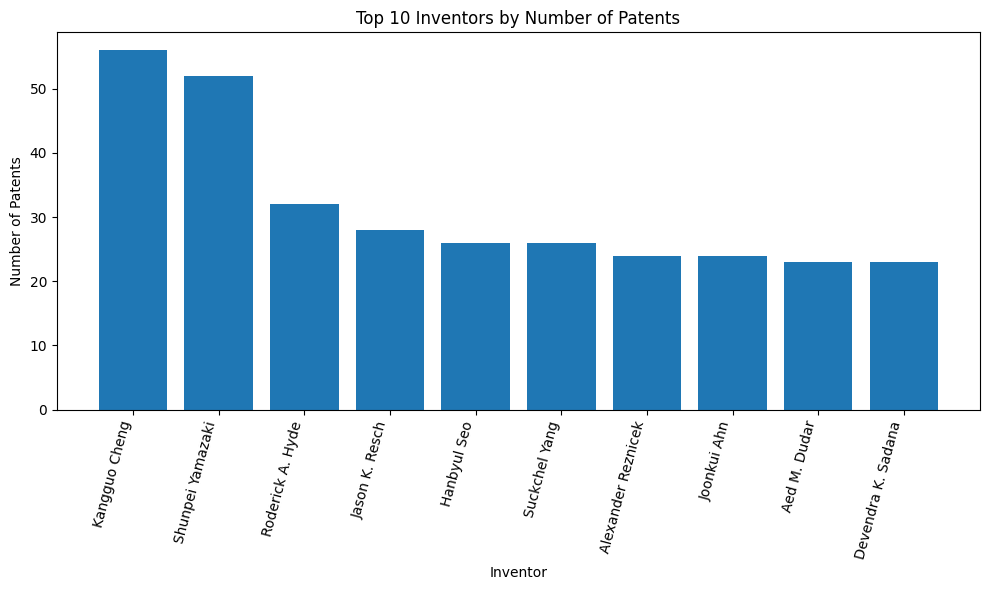

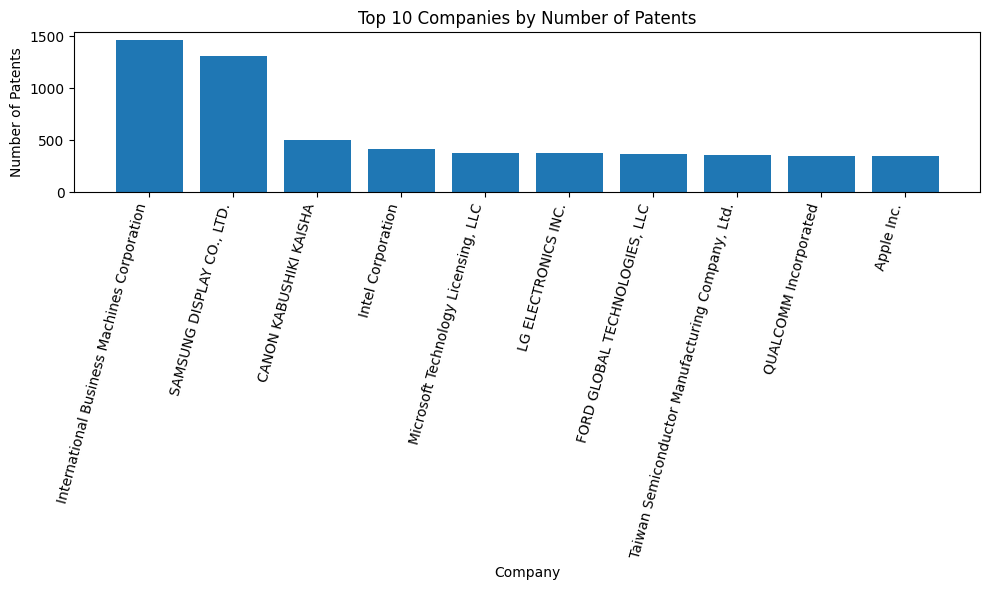

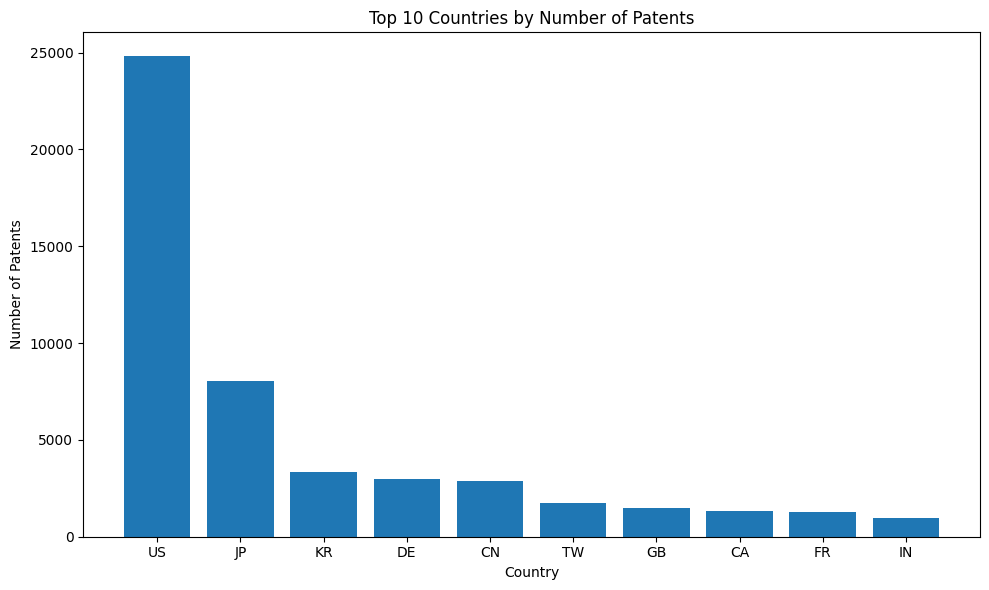

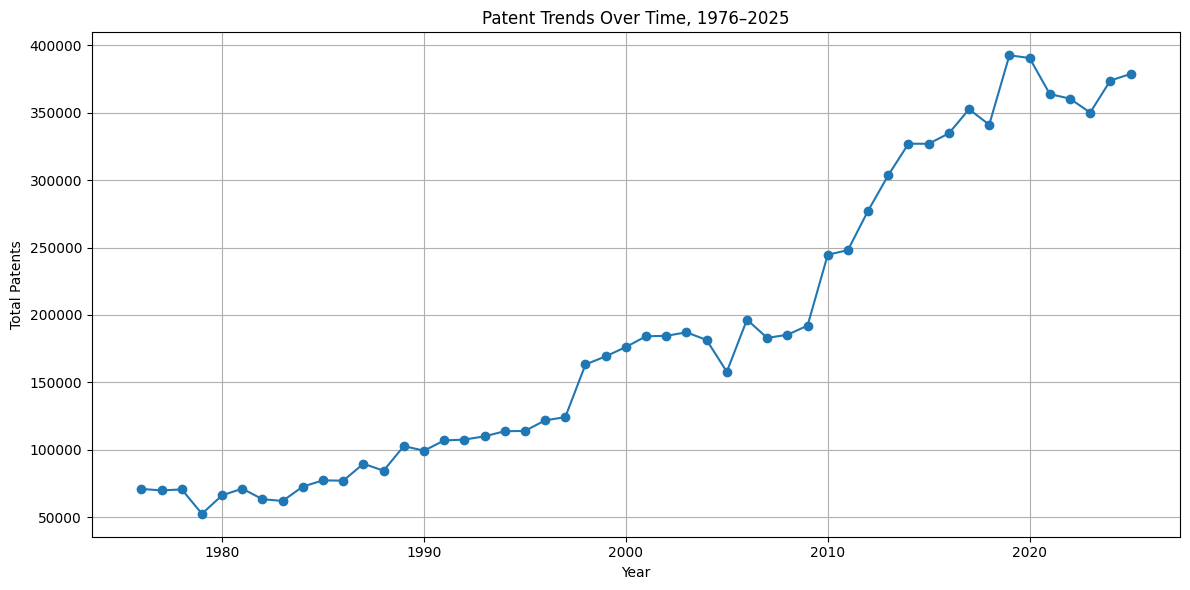

Graphs created successfully ✅
Files saved in reports folder:
- top_companies.png
- top_countries.png
- top_inventors.png
- yearly_patent_trends.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)


# LOAD REPORT FILES


top_inventors = pd.read_csv(REPORTS_DIR / "top_inventors.csv")
top_companies = pd.read_csv(REPORTS_DIR / "top_companies.csv")
top_countries = pd.read_csv(REPORTS_DIR / "top_countries.csv")
yearly_trends = pd.read_csv(REPORTS_DIR / "yearly_patent_trends_full.csv")


# 1. TOP INVENTORS BAR CHART


plt.figure(figsize=(10, 6))
plt.bar(top_inventors["name"], top_inventors["total_patents"])
plt.title("Top 10 Inventors by Number of Patents")
plt.xlabel("Inventor")
plt.ylabel("Number of Patents")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "top_inventors.png", dpi=300)
plt.show()


# 2. TOP COMPANIES BAR CHART


plt.figure(figsize=(10, 6))
plt.bar(top_companies["name"], top_companies["total_patents"])
plt.title("Top 10 Companies by Number of Patents")
plt.xlabel("Company")
plt.ylabel("Number of Patents")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "top_companies.png", dpi=300)
plt.show()


# 3. TOP COUNTRIES BAR CHART


plt.figure(figsize=(10, 6))
plt.bar(top_countries["country"], top_countries["total_patents"])
plt.title("Top 10 Countries by Number of Patents")
plt.xlabel("Country")
plt.ylabel("Number of Patents")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "top_countries.png", dpi=300)
plt.show()


# 4. YEARLY PATENT TRENDS LINE GRAPH


plt.figure(figsize=(12, 6))
plt.plot(yearly_trends["year"], yearly_trends["total_patents"], marker="o")
plt.title("Patent Trends Over Time, 1976–2025")
plt.xlabel("Year")
plt.ylabel("Total Patents")
plt.grid(True)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "yearly_patent_trends.png", dpi=300)
plt.show()

print("Graphs created successfully ")
print("Files saved in reports folder:")

for file in REPORTS_DIR.iterdir():
    if file.suffix.lower() == ".png":
        print("-", file.name)